# Plotting Asteroid Orbits

#### This tutorial demonstrates how to fetch orbits from the MPC's Orbits API, build a REBOUND simulation, and plot the orbits of asteroids from several dynamical classes.

We will:
1. Fetch the orbits of eight well-known asteroids — near-Earth objects, main-belt asteroids, a Jupiter Trojan, and a Centaur — from the MPC Orbits API
2. Propagate them to a common epoch so their positions can be shown together
3. Build a [REBOUND](https://rebound.readthedocs.io/) simulation containing the Sun, the planets, and the asteroids
4. Make quick-look plots with REBOUND's built-in `OrbitPlot` and `OrbitPlotSet` tools
5. Build a custom, publication-style figure with orbits coloured by dynamical class
6. Scale up to **thousands** of orbits: a JPL-style diagram of every potentially hazardous asteroid, using the MPC's bulk orbit files
7. Scale up again to the **full catalogue**: a snapshot of 1.5 million orbits from `MPCORB.DAT`, revealing the main belt, the Hildas, and the Jupiter Trojans

REBOUND comes with convenient built-in orbit plotting, so a quick visualisation is only one line of code; for full control we then draw our own figure directly with matplotlib.

Further information:
- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [MPC Orbits API tutorial notebook](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_api_orbits/)
- [REBOUND documentation](https://rebound.readthedocs.io/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)


## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion N-body tutorial, you can simply reuse it — no new packages are needed.


# Install and Import Packages

We need `requests` to talk to the MPC Orbits API, `rebound` to handle the orbits, and `numpy` / `matplotlib` for the custom figure.


In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt

import rebound


# Step 1: Fetch the Orbits

We select eight asteroids spanning four dynamical classes:

| Class | Objects |
|---|---|
| Near-Earth object (NEO) | Apophis, Eros, Phaethon |
| Main-belt asteroid | Ceres, Vesta, Pallas |
| Jupiter Trojan | Achilles |
| Centaur | Chiron |

The MPC Orbits API returns each orbit in the standardised [mpc_orb JSON format](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/mpc-orb-json/). We reuse the small `get_orbit` helper from the [Orbits API tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_api_orbits/) and read the JSON dictionaries directly.


In [2]:
# The objects we will plot, with their dynamical classes
ASTEROIDS = {
    "Apophis":  "NEO",
    "Eros":     "NEO",
    "Phaethon": "NEO",
    "Ceres":    "Main belt",
    "Vesta":    "Main belt",
    "Pallas":   "Main belt",
    "Achilles": "Jupiter Trojan",
    "Chiron":   "Centaur",
}

def get_orbit(designation):
    """Fetch the mpc_orb JSON dictionary for one object from the MPC Orbits API."""
    response = requests.get(
        "https://data.minorplanetcenter.net/api/get-orb",
        json={"desig": designation}
    )
    response.raise_for_status()
    result = response.json()
    if result and result[0].get("mpc_orb"):
        return result[0]["mpc_orb"][0]
    raise ValueError(f"No orbit returned for {designation!r}")

orbits = {}
print(f"{'Object':<10} {'Class':<15} {'Epoch (MJD, TT)':>16}")
print("-" * 43)
for name, cls in ASTEROIDS.items():
    orbits[name] = get_orbit(name)
    print(f"{name:<10} {cls:<15} {orbits[name]['epoch_data']['epoch']:>16.1f}")


Object     Class            Epoch (MJD, TT)
-------------------------------------------
Apophis    NEO                      60400.0
Eros       NEO                      61200.0
Phaethon   NEO                      61200.0
Ceres      Main belt                61000.0
Vesta      Main belt                61000.0
Pallas     Main belt                61200.0
Achilles   Jupiter Trojan           61200.0
Chiron     Centaur                  61200.0


# Step 2: Bring Everything to a Common Epoch

Notice that the epochs above **differ from object to object** (for example Apophis at MJD 60400.0, Ceres and Vesta at MJD 61000.0, and the rest at MJD 61200.0). Each orbit is an *osculating* solution valid at its own epoch.

For plotting the orbital *ellipses* this hardly matters — an osculating ellipse changes only very slowly. But we also want to mark **where each object is** along its orbit, and those position markers are only meaningful if every state vector refers to the same instant.

We therefore propagate each Cartesian state to the latest epoch in the set, MJD 61200.0, with a simple **two-body** (Sun + asteroid) REBOUND integration. The `CAR` coefficient values in the mpc_orb JSON are the heliocentric ecliptic position and velocity in AU and AU/day, so we set the simulation units to `('AU', 'day', 'Msun')` to match. Ignoring planetary perturbations over these gaps (at most 800 days) shifts the positions by far less than the resolution of our plots.


In [3]:
COMMON_EPOCH = 61200.0   # MJD (TT)

def state_at_common_epoch(mpc_orb, common_epoch_mjd):
    """Two-body propagate a Cartesian state vector to the common epoch.

    The mpc_orb 'CAR' coefficients are the heliocentric ecliptic
    position (AU) and velocity (AU/day) at the orbit's own epoch.
    """
    state = np.array(mpc_orb["CAR"]["coefficient_values"][:6])
    dt = common_epoch_mjd - mpc_orb["epoch_data"]["epoch"]   # days
    if dt == 0:
        return state
    s = rebound.Simulation()
    s.units = ("AU", "day", "Msun")     # match the MPC units
    s.add(m=1.0)                        # the Sun
    s.add(x=state[0], y=state[1], z=state[2],
          vx=state[3], vy=state[4], vz=state[5])
    s.integrate(dt)
    p = s.particles[1]
    return np.array([p.x, p.y, p.z, p.vx, p.vy, p.vz])

states = {name: state_at_common_epoch(orb, COMMON_EPOCH)
          for name, orb in orbits.items()}
print(f"All {len(states)} state vectors now refer to MJD {COMMON_EPOCH}")


All 8 state vectors now refer to MJD 61200.0


# Step 3: Build the Master Simulation

Now we build a single REBOUND simulation containing the Sun, the eight planets, and our eight asteroids, all at MJD 61200.0. REBOUND can load the Sun and planets directly from JPL Horizons by name.

Two details to be careful about:

- **Units and frames:** we set `sim.units = ('AU', 'day', 'Msun')` *before* adding any particles, so REBOUND matches the MPC units. REBOUND's Horizons interface returns *barycentric* ecliptic coordinates, while the MPC state vectors are *heliocentric* — so we add each asteroid's coordinates relative to the Sun particle.
- The `"Earth"` particle loaded from Horizons is actually the **Earth–Moon barycenter**, so do **not** also add the Moon as a separate body.

NB: It is possible that you may experience the following error when adding planets to REBOUND (which uses the NASA Horizons system to extract the planetary positions): `RuntimeError: An error occured while accessing NASA HORIZONS. If this is a SSL certificate issue, you can try disabling the certificate verification by setting rebound.horizons.SSL_CONTEXT = 'unverified'.`
 - In this scenario, the simplest approach is to just retry the evaluation, and this typically will succeed.


In [4]:
jd = COMMON_EPOCH + 2400000.5     # convert MJD -> JD for Horizons

sim = rebound.Simulation()
sim.units = ("AU", "day", "Msun")   # set BEFORE adding particles

planets = ["Sun", "Mercury", "Venus", "Earth", "Mars",
           "Jupiter", "Saturn", "Uranus", "Neptune"]
for body in planets:
    sim.add(body, date=f"JD{jd:.6f}")
    print(f"Added {body}")

# Horizons-loaded particles are barycentric; the MPC states are
# heliocentric, so add each asteroid relative to the Sun particle
sun = sim.particles[0]
for name in ASTEROIDS:
    st = states[name]
    sim.add(x=sun.x + st[0], y=sun.y + st[1], z=sun.z + st[2],
            vx=sun.vx + st[3], vy=sun.vy + st[4], vz=sun.vz + st[5])
print(f"Added {len(ASTEROIDS)} asteroids")

print(f"\nSimulation contains {sim.N} particles")


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Added Sun
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Added Mercury
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Added Venus
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Added Earth
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Added Mars
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Added Jupiter
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Added Saturn
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Added Uranus
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Added Neptune
Added 8 asteroids

Simulation cont

As a sanity check, let's convert each asteroid's state vector back into Keplerian elements with `particle.orbit(primary=sun)`. The values should look familiar: Phaethon's extreme eccentricity (e ≈ 0.89), Pallas's large inclination (i ≈ 35°), Achilles at Jupiter's semi-major axis (a ≈ 5.2 AU), and Chiron out among the giant planets (a ≈ 13.7 AU).


In [5]:
print(f"{'Object':<10} {'Class':<15} {'a (AU)':>8} {'e':>7} {'i (deg)':>8}")
print("-" * 52)
for k, (name, cls) in enumerate(ASTEROIDS.items()):
    o = sim.particles[len(planets) + k].orbit(primary=sun)
    print(f"{name:<10} {cls:<15} {o.a:>8.3f} {o.e:>7.3f} {np.degrees(o.inc):>8.2f}")


Object     Class             a (AU)       e  i (deg)
----------------------------------------------------
Apophis    NEO                0.923   0.191     3.34
Eros       NEO                1.458   0.223    10.83
Phaethon   NEO                1.271   0.890    22.31
Ceres      Main belt          2.766   0.080    10.59
Vesta      Main belt          2.362   0.090     7.14
Pallas     Main belt          2.770   0.231    34.93
Achilles   Jupiter Trojan     5.216   0.148    10.32
Chiron     Centaur           13.684   0.380     6.93


# Step 4: Quick Look with `rebound.OrbitPlot`

REBOUND's built-in [`OrbitPlot`](https://rebound.readthedocs.io/en/latest/plotting/) draws every orbit in the simulation with a single call. The returned object exposes the underlying matplotlib figure and axes as `.fig` and `.ax`, so you can customise or save the result afterwards.

Useful parameters include:

- `projection` — `"xy"` (top-down, the default), `"xz"`, or `"yz"` for edge-on views
- `particles` — a list of particle indices to plot (default: everything except the primary)
- `color` — `True` cycles a colour per orbit (you can also pass a list of colours)
- `orbit_style` — `"trail"` (fading, shows direction of motion), `"solid"`, or `"none"`
- `periastron` — mark each orbit's periastron

Plotting all 16 orbits at once compresses the inner Solar System into an unreadable blob at the centre, so here we use `particles=` to show only Mercury through Jupiter (indices 1–5) plus the NEOs and main-belt asteroids (indices 9–14).


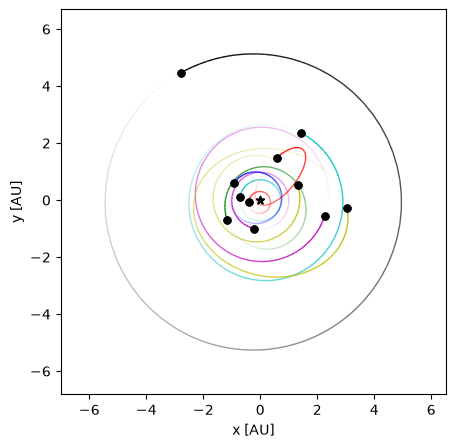

In [6]:
# Inner planets (1-5: Mercury..Jupiter) + inner asteroids (9-14: Apophis..Pallas)
inner = list(range(1, 6)) + list(range(9, 15))

op = rebound.OrbitPlot(sim, unitlabel="[AU]", color=True, particles=inner)


# Step 5: Three Projections with `rebound.OrbitPlotSet`

A top-down view hides the third dimension. `OrbitPlotSet` draws the same simulation in all three projections at once: the main panel is the familiar top-down (x, y) view, while the side panels show the (x, z) and (z, y) edge-on views.

This time we plot the **full** simulation, out to Neptune and Chiron. In the edge-on panels the inclined orbits stand out immediately — watch for Pallas and Chiron tilting well out of the ecliptic plane.


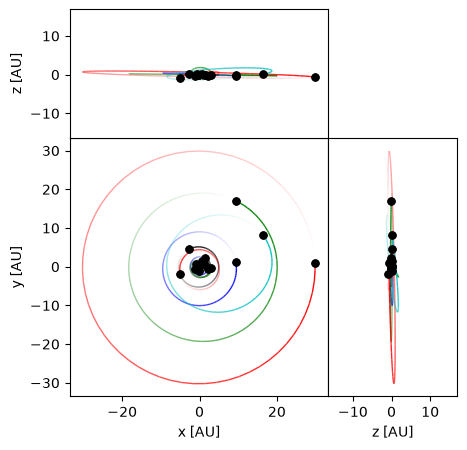

In [7]:
import logging
# OrbitPlotSet's equal-aspect axes trigger a harmless matplotlib notice
# ("Ignoring fixed x/y limits..."); silence that one logger
logging.getLogger("matplotlib.axes._base").setLevel(logging.ERROR)

ops = rebound.OrbitPlotSet(sim, unitlabel="[AU]", color=True)


# Step 6: A Custom Publication-Style Figure

The built-in plots are great for a quick look, but for a figure you would put in a talk or a paper you usually want full control: orbits coloured by *meaning* (here, dynamical class), planets drawn as recessive grey context, objects labelled directly, and chosen projections.

The key REBOUND tool is `particle.sample_orbit(Npts, primary=sun)`, which returns points along the particle's osculating orbit — we simply draw them with matplotlib.

We build two stacked panels: a top-down (x, y) view of the inner Solar System out to ±6.5 AU, and an edge-on (x, z) view beneath it. One design choice: **Chiron is excluded from this figure** — its 13.7 AU orbit lies entirely outside our frame (you already saw it in the `OrbitPlotSet` view above).


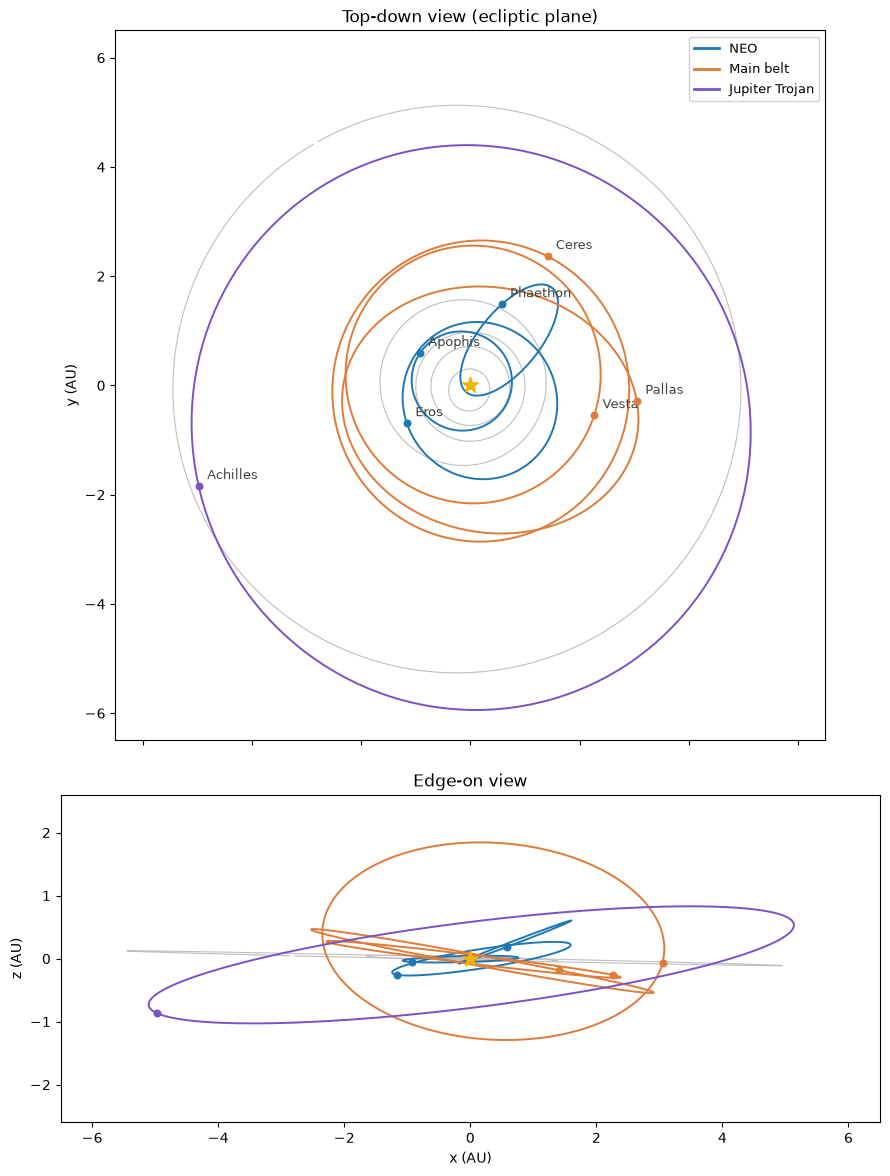

In [8]:
# Colour per dynamical class (Chiron/"Centaur" is out of frame and excluded)
CLASS_COLORS = {
    "NEO":            "#1f77b4",
    "Main belt":      "#e07b39",
    "Jupiter Trojan": "#7a52c7",
}

fig, (ax_xy, ax_xz) = plt.subplots(
    2, 1, figsize=(9, 12), height_ratios=[2, 1], sharex=True)

for ax, (ix, iy) in [(ax_xy, (0, 1)), (ax_xz, (0, 2))]:
    # Planets Mercury..Jupiter as recessive grey context
    for i in range(1, 6):
        pts = np.array(sim.particles[i].sample_orbit(Npts=300, primary=sun))
        ax.plot(pts[:, ix], pts[:, iy], color="0.75", lw=0.8, zorder=1)

    # Asteroids coloured by dynamical class, with a dot at the current position
    for k, (name, cls) in enumerate(ASTEROIDS.items()):
        if cls not in CLASS_COLORS:     # skip Chiron: out of frame
            continue
        p = sim.particles[len(planets) + k]
        color = CLASS_COLORS[cls]
        pts = np.array(p.sample_orbit(Npts=300, primary=sun))
        ax.plot(pts[:, ix], pts[:, iy], color=color, lw=1.4, zorder=2)
        rel = [p.x - sun.x, p.y - sun.y, p.z - sun.z]
        ax.scatter([rel[ix]], [rel[iy]], s=22, color=color, zorder=3)
        if ax is ax_xy:                 # direct labels in the top-down panel only
            ax.annotate(name, (rel[ix], rel[iy]), textcoords="offset points",
                        xytext=(6, 5), fontsize=9, color="0.25")

    ax.scatter([0], [0], marker="*", s=140, color="#f4b400", zorder=4)  # the Sun
    ax.set_aspect("equal")
    ax.set_xlim(-6.5, 6.5)

ax_xy.set_ylim(-6.5, 6.5)
ax_xz.set_ylim(-2.6, 2.6)
ax_xy.set_ylabel("y (AU)")
ax_xz.set_ylabel("z (AU)")
ax_xz.set_xlabel("x (AU)")
ax_xy.set_title("Top-down view (ecliptic plane)")
ax_xz.set_title("Edge-on view")

handles = [plt.Line2D([], [], color=c, lw=2, label=cls)
           for cls, c in CLASS_COLORS.items()]
ax_xy.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
fig.tight_layout()
plt.show()


### Reading the figure

A few features worth noticing:

- **Phaethon** (e = 0.89) traces the long blue ellipse that dives *inside* Mercury's orbit at perihelion — this extreme orbit is why it is the parent body of the Geminid meteor shower.
- **Pallas** dominates the edge-on view: its 35° inclination carries it more than 2 AU above and below the ecliptic plane, while the other main-belt orbits stay comparatively flat.
- **Achilles** shares Jupiter's orbit at 5.2 AU — it is a Jupiter Trojan, librating around a point 60° ahead of the planet.
- The three **NEO** orbits all thread the tight cluster of grey terrestrial-planet orbits at the centre, which is exactly what makes them "near-Earth" objects.


# Step 7: Thousands of Orbits: PHA Diagram

The same techniques scale up. 

A [NASA/JPL-Caltech visualization](https://d2pn8kiwq2w21t.cloudfront.net/original_images/1_orbital-diagram.jpg) shows the orbits of over 2,000 potentially hazardous asteroids (PHAs) as a dense web of thin blue ellipses around the inner Solar System. 

Here we recreate that style using MPC data.

Querying the Orbits API a few thousand times would be slow and impolite. For bulk work the MPC publishes **orbit catalogue files**: see the [MPC data page](https://minorplanetcenter.net/data) and the [lists of minor planets](https://data.minorplanetcenter.net/lists/). 
The file `pha_extended.json.gz` contains the Keplerian elements of every PHA (about 2,500 objects at the time of writing) as gzipped JSON, only a few hundred kB in total, and all at the same standard epoch, so no epoch alignment is needed this time.


In [9]:
import gzip
import json

# Download the PHA catalogue (about 300 kB compressed)
resp = requests.get(
    "https://minorplanetcenter.net/Extended_Files/pha_extended.json.gz",
    timeout=120)
resp.raise_for_status()
phas = json.loads(gzip.decompress(resp.content))

print(f"Loaded {len(phas)} PHAs at epoch JD {phas[0]['Epoch']}")
print("Element fields per object include: a, e, i, Node, Peri, M (angles in degrees)")
example = phas[0]
print(f"\nExample -- {example['Number']} {example['Name']}: "
      f"a={example['a']} AU, e={example['e']}, i={example['i']} deg")


Loaded 2541 PHAs at epoch JD 2461200.5
Element fields per object include: a, e, i, Node, Peri, M (angles in degrees)

Example -- (1566) Icarus: a=1.0779942 AU, e=0.8270189, i=22.80162 deg


This time we have Keplerian elements rather than Cartesian state vectors, so we let REBOUND do the conversion: `sim.add(primary=..., a=..., e=..., inc=..., Omega=..., omega=..., M=...)` places a particle from its elements (angles in **radians**). The catalogue epoch (JD 2461200.5 = MJD 61200.0 TT) matches the epoch of our master simulation, so we build the new simulation the same way, with the Sun and the four inner planets from Horizons.

One REBOUND subtlety when adding *many* particles: a variable like `sun = sim.particles[0]` is a live reference into REBOUND's internal particle array, and adding thousands of particles can reallocate that array, leaving the reference stale. We therefore pass `primary=sim.particles[0]` (fetched fresh) while adding, and re-fetch `sun` once all particles are in place.


In [10]:
# Fresh simulation: Sun + inner planets at the PHA catalogue epoch
jd_pha = phas[0]["Epoch"]
sim_pha = rebound.Simulation()
sim_pha.units = ("AU", "day", "Msun")
pha_planets = ["Sun", "Mercury", "Venus", "Earth", "Mars"]
for body in pha_planets:
    sim_pha.add(body, date=f"JD{jd_pha:.6f}")

# Add every PHA from its Keplerian elements (catalogue angles are in degrees)
for o in phas:
    sim_pha.add(primary=sim_pha.particles[0],
                a=o["a"], e=o["e"], inc=np.radians(o["i"]),
                Omega=np.radians(o["Node"]), omega=np.radians(o["Peri"]),
                M=np.radians(o["M"]))
print(f"Simulation contains {sim_pha.N} particles")

# Re-fetch the Sun reference now that the particle array is final
sun_pha = sim_pha.particles[0]

# Collect one (x, y) polyline per PHA orbit
n_pl = len(pha_planets)
pha_orbit_xy = []
for k in range(len(phas)):
    pts = np.array(sim_pha.particles[n_pl + k].sample_orbit(
        Npts=120, primary=sun_pha))
    pha_orbit_xy.append(pts[:, :2])
print(f"Sampled {len(pha_orbit_xy)} orbit polylines")


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Simulation contains 2546 particles
Sampled 2541 orbit polylines


Now the figure. The trick that makes the "web" work is drawing every orbit as a **very thin, translucent** line on a black background: where many orbits overlap, the transparency accumulates into a bright haze, so line density becomes visible structure. A matplotlib `LineCollection` renders all 2,500 polylines in a single artist, which is much faster than 2,500 separate `plot` calls.

On top of the web we draw the inner-planet orbits in bright white, mark each planet's position, and — as a nod to the original JPL figure — highlight (65803) Didymos, the target of the DART planetary-defense mission (and itself a PHA in our catalogue).


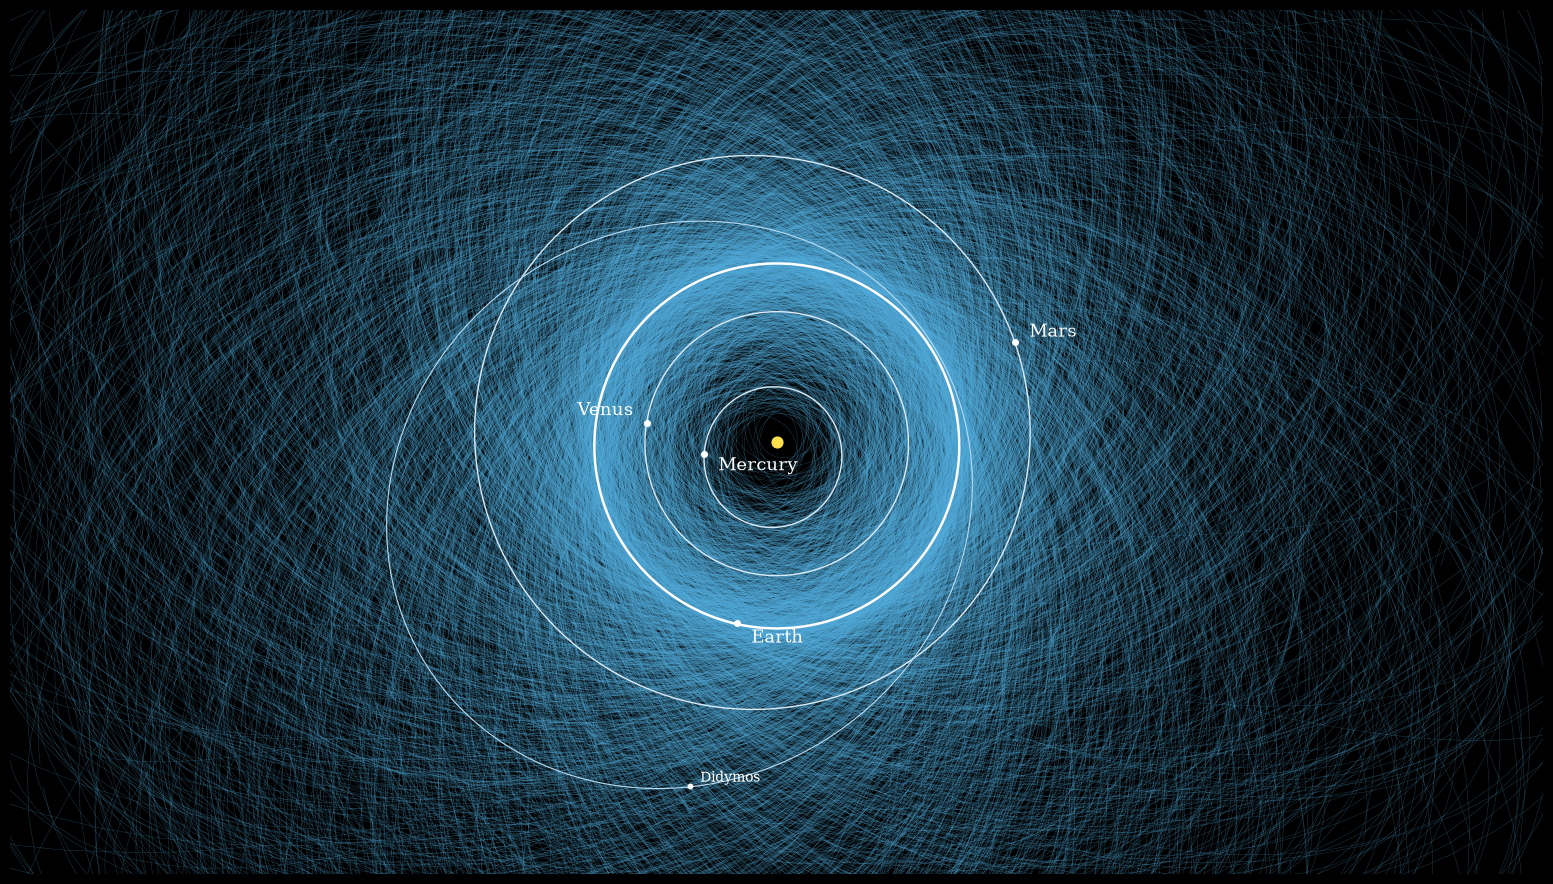

In [11]:
from matplotlib.collections import LineCollection

fig, ax = plt.subplots(figsize=(15.33, 8.64), dpi=100)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# The web: all PHA orbits as one LineCollection of thin translucent lines
ax.add_collection(LineCollection(pha_orbit_xy, colors="#55b0e0",
                                 linewidths=0.35, alpha=0.32))

# Inner-planet orbits, positions, and labels
planet_style = {           # color, linewidth, label offset (points), alignment
    "Mercury": ("#dcecf7", 1.0, (10, -12), "left"),
    "Venus":   ("#dcecf7", 1.0, (-10, 6), "right"),
    "Earth":   ("white",   1.8, (10, -14), "left"),
    "Mars":    ("#dcecf7", 1.0, (10, 4), "left"),
}
for i, name in enumerate(pha_planets[1:], start=1):
    p = sim_pha.particles[i]
    col, lw, offset, halign = planet_style[name]
    pts = np.array(p.sample_orbit(Npts=300, primary=sun_pha))
    ax.plot(pts[:, 0], pts[:, 1], color=col, lw=lw, zorder=5)
    ax.scatter([p.x - sun_pha.x], [p.y - sun_pha.y], s=16, color="white", zorder=6)
    ax.annotate(name, (p.x - sun_pha.x, p.y - sun_pha.y),
                textcoords="offset points", xytext=offset, ha=halign,
                fontsize=13, color="white", family="serif", zorder=7)

# Highlight Didymos: brighter orbit, position dot, and label
i_didymos = next(k for k, o in enumerate(phas) if o.get("Name") == "Didymos")
pd = sim_pha.particles[n_pl + i_didymos]
pts_d = np.array(pd.sample_orbit(Npts=300, primary=sun_pha))
ax.plot(pts_d[:, 0], pts_d[:, 1], color="#b8dcf2", lw=0.8, zorder=5)
ax.scatter([pd.x - sun_pha.x], [pd.y - sun_pha.y], s=10, color="white", zorder=6)
ax.annotate("Didymos", (pd.x - sun_pha.x, pd.y - sun_pha.y),
            textcoords="offset points", xytext=(7, 3),
            fontsize=10, color="white", family="serif", zorder=7)

# The Sun
ax.scatter([0], [0], s=60, color="#ffe14d", zorder=6)

# 16:9 frame, no axes
half_w = 4.2
half_h = half_w * 864 / 1533
ax.set_xlim(-half_w, half_w)
ax.set_ylim(-half_h, half_h)
ax.set_aspect("equal")
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()


Every thin blue line is the orbit of a real potentially hazardous asteroid — an object larger than roughly 140 m whose orbit brings it within 0.05 AU of Earth's. The bright haze between roughly 1 and 2 AU is not an artefact: it is where PHA orbits crowd together, by the very definition of the population.

Two honest caveats about a figure like this: it projects three-dimensional orbits onto the ecliptic plane (many of these orbits are strongly inclined, as Step 5 showed), and it draws each osculating ellipse as if fixed in time, whereas the real orbits precess and evolve. As art and as a population overview it is superb; for any quantitative statement, work with the elements themselves.

*(Figure style inspired by the NASA/JPL-Caltech PHA orbit diagram; data: Minor Planet Center.)*


# Step 8: The Main Belt — 1.5 Million Orbits from MPCORB

For the *whole* catalogue we step up to the MPC's flagship orbit file, [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html): roughly 1.5 **million** orbits in a fixed-width text format, about 90 MB gzipped. The column layout is documented on the [Minor Planet Orbit Format page](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/); we slice just the six Keplerian elements and the epoch out of each line, streaming the gzipped file so the raw text is never held in memory.

**Download note:** the cell below caches `MPCORB.DAT.gz` (about 90 MB) in the notebook's working directory and only downloads it if it is not already present. Delete the file to reclaim the space when you are done.


In [12]:
import os
import collections

MPCORB_URL = "https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT.gz"
MPCORB_FILE = "MPCORB.DAT.gz"

if not os.path.exists(MPCORB_FILE):
    print(f"Downloading {MPCORB_URL} (about 90 MB; this may take a few minutes)")
    with requests.get(MPCORB_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(MPCORB_FILE + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(MPCORB_FILE + ".part", MPCORB_FILE)
    print("  done")
else:
    print(f"Using cached {MPCORB_FILE}")

# Fixed-width columns (1-indexed, from the orbit-format documentation):
# epoch 21-25 (packed), M 27-35, Peri 38-46, Node 49-57,
# i 60-68, e 71-79, a 93-103
rows = []
epoch_counts = collections.Counter()
with gzip.open(MPCORB_FILE, "rt") as f:
    in_header = True
    for line in f:
        if in_header:                      # header ends at a dashed line
            if line.startswith("----------"):
                in_header = False
            continue
        if len(line) < 104:                # skip blank section separators
            continue
        try:
            elems = (float(line[92:103]), float(line[70:79]),
                     float(line[59:68]), float(line[48:57]),
                     float(line[37:46]), float(line[26:35]))
        except ValueError:                 # rare rows with missing elements
            continue
        rows.append(elems + (line[20:25],))
        epoch_counts[line[20:25]] += 1

print(f"\nParsed {len(rows):,} orbits")
epoch_mode, n_mode = epoch_counts.most_common(1)[0]
print(f"Most common epoch: {epoch_mode!r} ({n_mode:,} orbits, "
      f"{100 * n_mode / len(rows):.1f} percent of the catalogue)")


  done

Parsed 1,562,078 orbits
Most common epoch: 'K2669' (1,552,194 orbits, 99.4 percent of the catalogue)


Almost the whole catalogue shares one standard epoch (the packed code `K2669` decodes to 2026-06-09 — the same MJD 61200.0 we have used throughout; see the [packed dates documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/designations/packed-dates/)). We keep only those orbits, so every dot in the figure refers to the same instant.

At this scale a different plotting strategy pays off, in two ways:

- **Positions, not ellipses.** Drawing 1.5 million overlapping ellipses would wash out into a featureless ring. Instead we plot a **snapshot**: one dot per asteroid at its position on the common epoch. Structure in the *positions* — the belt annulus, resonant groups — then becomes visible.
- **Vectorized Kepler, not a particle per object.** Adding a million particles to REBOUND one at a time is slow in Python. Since we only need two-body positions from elements, we solve Kepler's equation `E - e sin E = M` for **all objects at once** with a few vectorized Newton iterations, then rotate into the ecliptic frame. (We cross-check the result against REBOUND for a handful of objects.)

We also **subsample with intent**. Following the population sizes, a uniform random subsample would nearly erase two small groups with spectacular structure: the **Hildas** (interior 3:2 resonance with Jupiter, a ≈ 3.7–4.2 AU) and the **Jupiter Trojans** (1:1, a ≈ 5.0–5.4 AU). So we keep *all* of those and subsample only the vastly more numerous rest.


In [13]:
# Orbits at the common epoch, inside Jupiter's neighbourhood
el = np.array([r[:6] for r in rows if r[6] == epoch_mode])
el = el[(el[:, 0] > 0) & (el[:, 0] < 6.0) & (el[:, 1] < 1.0)]
print(f"{len(el):,} orbits with a < 6 AU at the common epoch")

# Stratified subsample: keep ALL Hildas and Trojans, subsample the rest
rng = np.random.default_rng(42)
N_BELT = 200_000
a_all = el[:, 0]
special = ((a_all >= 3.7) & (a_all <= 4.2)) | ((a_all >= 5.0) & (a_all <= 5.4))
belt_rows = el[~special]
keep = rng.choice(len(belt_rows), min(N_BELT, len(belt_rows)), replace=False)
el = np.vstack([belt_rows[keep], el[special]])
print(f"Subsampled to {len(el):,} ({special.sum():,} Hildas + Trojans kept in full)")

# Vectorized two-body positions from Keplerian elements
a, e = el[:, 0], el[:, 1]
inc, node, peri, M = np.radians(el[:, 2:6]).T

E = M.copy()                             # solve Kepler: E - e sin E = M
for _ in range(30):                      # Newton iterations, all objects at once
    E -= (E - e * np.sin(E) - M) / (1 - e * np.cos(E))

xp = a * (np.cos(E) - e)                 # position in the orbital plane
yp = a * np.sqrt(1 - e**2) * np.sin(E)

cw, sw = np.cos(peri), np.sin(peri)      # rotate: R_z(node) R_x(inc) R_z(peri)
ci, si = np.cos(inc), np.sin(inc)
cO, sO = np.cos(node), np.sin(node)
x1, y1 = cw * xp - sw * yp, sw * xp + cw * yp
x = cO * x1 - sO * ci * y1
y = sO * x1 + cO * ci * y1

# Cross-check the vectorized solver against REBOUND for the first 5 objects
s = rebound.Simulation()
s.units = ("AU", "day", "Msun")
s.add(m=1.0)
for k in range(5):
    s.add(primary=s.particles[0], a=a[k], e=e[k], inc=inc[k],
          Omega=node[k], omega=peri[k], M=M[k])
for k in range(5):
    p = s.particles[k + 1]
    assert abs(p.x - x[k]) < 1e-9 and abs(p.y - y[k]) < 1e-9
print("Vectorized Kepler solver agrees with REBOUND")


1,544,495 orbits with a < 6 AU at the common epoch
Subsampled to 224,301 (24,301 Hildas + Trojans kept in full)
Vectorized Kepler solver agrees with REBOUND


Catalogue epoch: 2026-06-09
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')


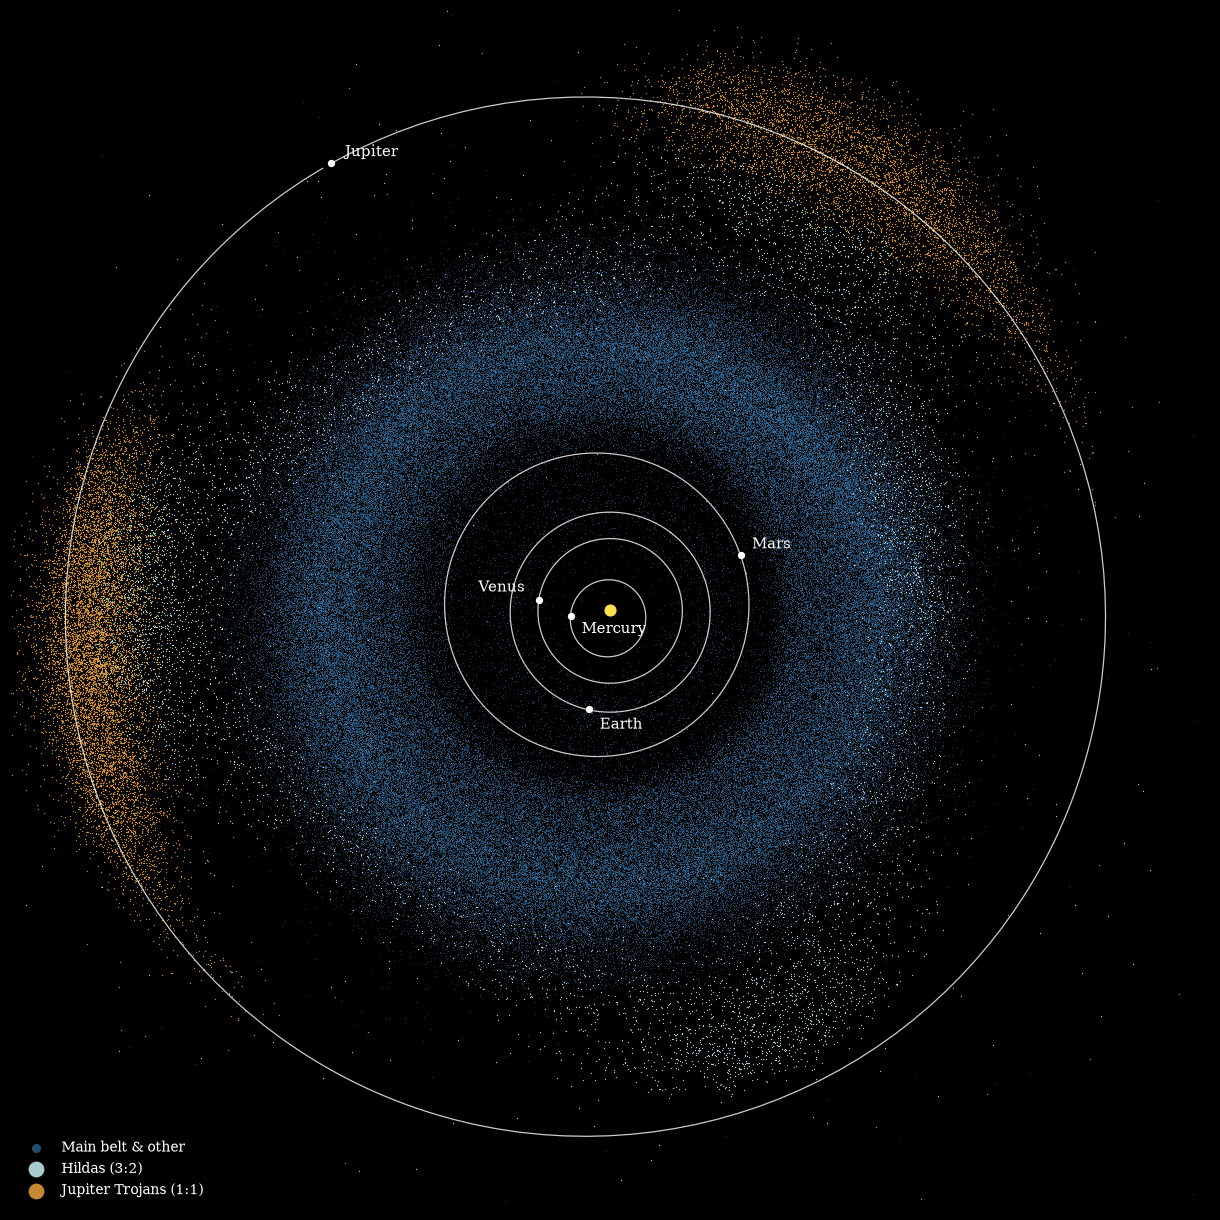

In [14]:
# Decode the packed epoch (e.g. 'K2669' -> 2026-06-09) for the planet query
def unpack_epoch(packed):
    century = {"I": 18, "J": 19, "K": 20}[packed[0]]
    year = century * 100 + int(packed[1:3])
    month = int(packed[3], 36) if packed[3].isdigit() else ord(packed[3]) - 55
    day = int(packed[4], 36) if packed[4].isdigit() else ord(packed[4]) - 55
    return year, month, day

yr, mon, day = unpack_epoch(epoch_mode)
print(f"Catalogue epoch: {yr:04d}-{mon:02d}-{day:02d}")

# Sun + planets out to Jupiter at that epoch
sim_belt = rebound.Simulation()
sim_belt.units = ("AU", "day", "Msun")
for body in ["Sun", "Mercury", "Venus", "Earth", "Mars", "Jupiter"]:
    sim_belt.add(body, date=f"{yr:04d}-{mon:02d}-{day:02d} 00:00")
sun_belt = sim_belt.particles[0]

fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# One dot per asteroid, coloured by population
is_hilda = (a >= 3.7) & (a <= 4.2)
is_trojan = (a >= 5.0) & (a <= 5.4)
is_belt = ~(is_hilda | is_trojan)
ax.scatter(x[is_belt], y[is_belt], s=0.3, color="#3f89c4",
           alpha=0.55, lw=0, zorder=2, label="Main belt & other")
ax.scatter(x[is_hilda], y[is_hilda], s=0.9, color="#c9f0f4",
           alpha=0.85, lw=0, zorder=3, label="Hildas (3:2)")
ax.scatter(x[is_trojan], y[is_trojan], s=0.9, color="#e8a23c",
           alpha=0.85, lw=0, zorder=3, label="Jupiter Trojans (1:1)")
ax.legend(loc="lower left", fontsize=10, framealpha=0, markerscale=12,
          labelcolor="white", prop={"family": "serif"})

# Planet orbits, positions, and labels
label_offsets = {"Mercury": (8, -12), "Venus": (-10, 6), "Earth": (8, -14),
                 "Mars": (8, 5), "Jupiter": (10, 5)}
for i, name in enumerate(["Mercury", "Venus", "Earth", "Mars", "Jupiter"], start=1):
    p = sim_belt.particles[i]
    pts = np.array(p.sample_orbit(Npts=300, primary=sun_belt))
    ax.plot(pts[:, 0], pts[:, 1], color="white", lw=0.9, alpha=0.8, zorder=4)
    ax.scatter([p.x - sun_belt.x], [p.y - sun_belt.y], s=18, color="white", zorder=5)
    ax.annotate(name, (p.x - sun_belt.x, p.y - sun_belt.y),
                textcoords="offset points", xytext=label_offsets[name],
                ha="right" if name == "Venus" else "left",
                fontsize=11, color="white", family="serif", zorder=6)

ax.scatter([0], [0], s=60, color="#ffe14d", zorder=5)   # the Sun
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()


### Reading the figure

- The dense blue ring is the **main belt** between roughly 2.1 and 3.3 AU — over 90 percent of the known population lives here.
- The two orange clouds are the **Jupiter Trojans**, librating around the L4 and L5 Lagrange points 60° ahead of and behind Jupiter on its orbit.
- The pale triangle traced inside the belt's outer edge is the **Hilda group**: objects in the interior 3:2 resonance with Jupiter. Each Hilda visits an aphelion near L3, L4, or L5 in turn, so at any instant the population forms a triangle with vertices at those points — a resonance made visible in a single snapshot.
- One famous feature is *invisible* here: the **Kirkwood gaps** are gaps in semi-major axis, and orbital eccentricity smears them out in an (x, y) snapshot. To see them, histogram `el[:, 0]` — a worthwhile exercise.

Note that the sub-population colours separate by brightness as well as hue, and all pairs were checked for colour-vision-deficiency distinguishability.


# Going Further

Some ideas for building on this tutorial:

- **Animate the positions**: integrate the master simulation forward in small steps (`sim.integrate(t)`) and redraw the position markers at each step to watch the objects move along their orbits. (Animating the Step 8 snapshot makes the Hilda triangle rotate with Jupiter.)
- **Find the Kirkwood gaps**: histogram the semi-major axes from Step 8 — the gaps carved by Jupiter's mean-motion resonances appear immediately, even though the (x, y) snapshot hides them.
- **Colour by an orbital element**: instead of discrete classes, colour each orbit or point by a continuous quantity such as eccentricity or inclination using a sequential matplotlib colormap and a colorbar.
- **Go interactive in 3D**: feed the `sample_orbit` points into plotly for a rotatable 3D view of the inclined orbits.
- **Propagate uncertainty**: the [companion N-body tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/) shows how to sample orbital clones from the covariance matrix and integrate them to visualise how orbital uncertainty evolves.

A further tutorial on ephemeris-quality integrations with ASSIST is in preparation.


# Summary

In this tutorial we:

1. **Fetched** the orbits of eight asteroids across four dynamical classes from the MPC Orbits API
2. **Propagated** each Cartesian state to a common epoch (MJD 61200.0) with simple two-body integrations, so the position markers are mutually consistent
3. **Built** a REBOUND simulation of the Sun, planets, and asteroids, taking care with units (AU, day, Msun) and with the heliocentric/barycentric distinction
4. **Plotted** quick-look views with `rebound.OrbitPlot` (selected particles, top-down) and `rebound.OrbitPlotSet` (all three projections)
5. **Designed** a custom two-panel matplotlib figure using `sample_orbit`, with orbits coloured by dynamical class and objects labelled directly
6. **Scaled up** to the full population of roughly 2,500 potentially hazardous asteroids from the MPC's bulk orbit files, rendering their orbits as a JPL-style diagram with a matplotlib `LineCollection`
7. **Scaled up again** to the 1.5-million-orbit `MPCORB.DAT` catalogue: streaming fixed-width parsing, a vectorized Kepler solver, stratified subsampling, and a position snapshot that reveals the main belt, the Hilda triangle, and the Jupiter Trojan clouds

### Further Resources

- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [MPC Orbits API tutorial notebook](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_api_orbits/)
- [MPC data page (bulk orbit files)](https://minorplanetcenter.net/data), [lists of minor planets](https://data.minorplanetcenter.net/lists/), and the [MPCORB page](https://minorplanetcenter.net/iau/MPCORB.html)
- [Minor Planet Orbit Format documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/)
- [REBOUND documentation](https://rebound.readthedocs.io/) and its [plotting guide](https://rebound.readthedocs.io/en/latest/plotting/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).
